# Silent Spring

When the pesticide DDT was made available to the public in 1944, it was seen as a miracle chemical in the battle against insect pests. How did the worldwide availability of DDT coincide with word trends for insect words?

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'animal-word-trends-silent-spring.csv' and 'sparrowhawk-eggshell-data.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('animal-word-trends-silent-spring.csv')
df.head()

,year,word,frequency
0,1900,bedbug,0.102345
1,1900,condor,0.609499
2,1900,flea,1.829821
3,1900,fly,16.505119
4,1900,hawk,7.507158


In [3]:
def plot_insect_word_trend( animal ):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and the year DDT was made available')
    plt.axvline(1944, color='orange', ls='--')

Explore word trends for insects relative to 1944.

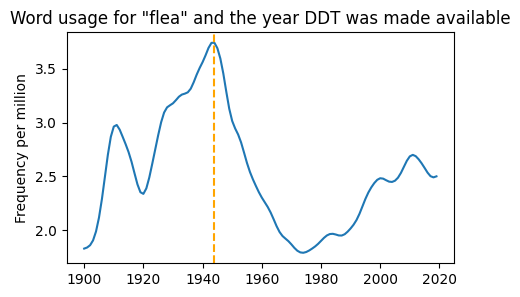

In [4]:
plot_insect_word_trend('flea')
# try flea, mosquito, fly, bedbug, louse

#### Impact of DDT

Early marketing for DDT claimed it only killed insect pests and did not affect other animals. The following python script might help shed light on this claim.

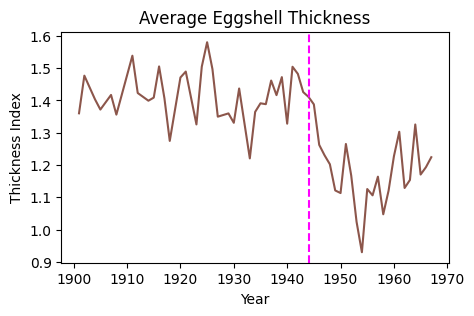

In [5]:
egg = pd.read_csv('sparrowhawk-eggshell-data.csv')
plt.figure(figsize=(5, 3))
plt.plot(egg['year'],egg['avg_thickness'], color='C5')
plt.xlabel('Year')
plt.ylabel('Thickness Index')
plt.title('Average Eggshell Thickness')
plt.axvline( 1944, color='magenta', ls='--', label='DDT made available to public' )
plt.show()

#### Rachel Carson

In 1962, Rachel Carson published the book Silent Spring, which showed that the toxins killing insects were also harming the rest of the food web. This book began to raise public awareness of DDT's toxicity, which eventually lead to bans on DDT.

In particular, birds of prey such as peregrine falcons, and songbirds such as robins, were highly affected by widespread use of DDT.

Use the function below to explore the word usage levels for these birds relative to the 1962 book.


In [6]:
def plot_bird_word_trend( animal ):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and the year Silent Spring published')
    plt.axvline(1962, color='orange', ls='--')

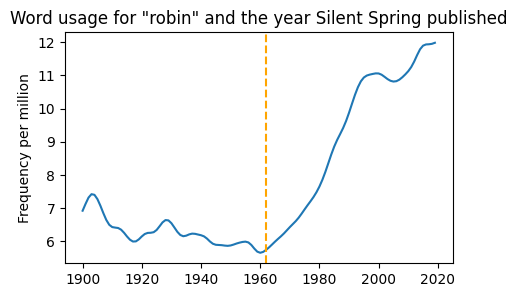

In [7]:
plot_bird_word_trend('robin')
# try robin, hawk, peregrine, osprey, sparrowhawk, condor

# Project Ideas

The widespread use of DDT led to decreasing populations for insects and birds.

- Describe the word usage patterns for birds and insects. How are they different?

- Explore potential explanations for these differences. 


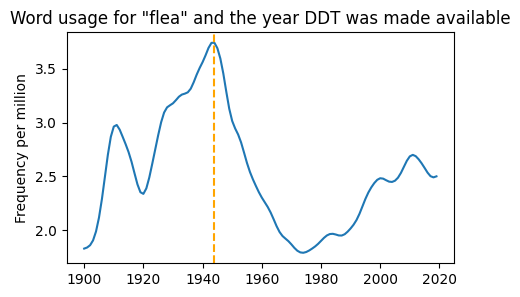

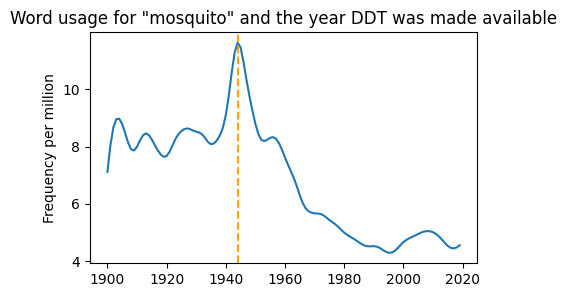

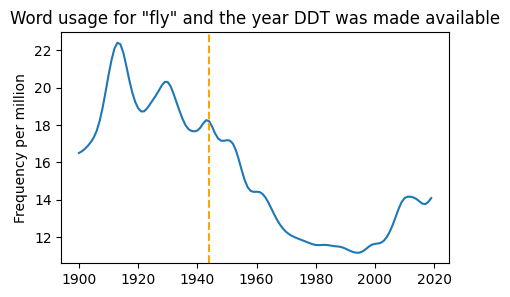

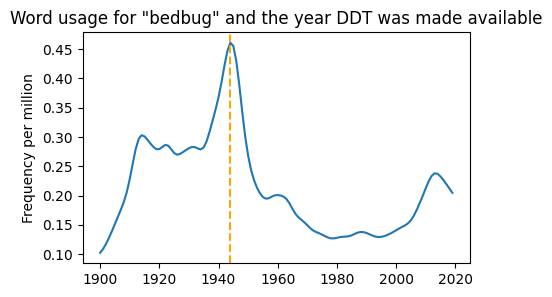

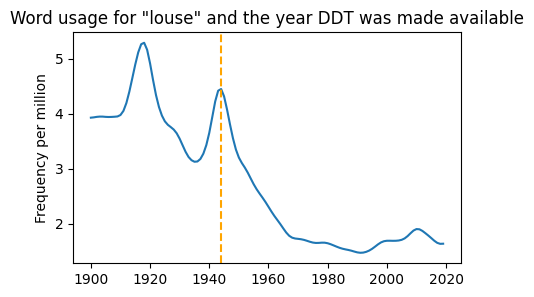

In [8]:
# ── 1. Insect word trends (relative to 1944 DDT introduction) ─────────────────
insects = ['flea', 'mosquito', 'fly', 'bedbug', 'louse']

for insect in insects:
    plot_insect_word_trend(insect)

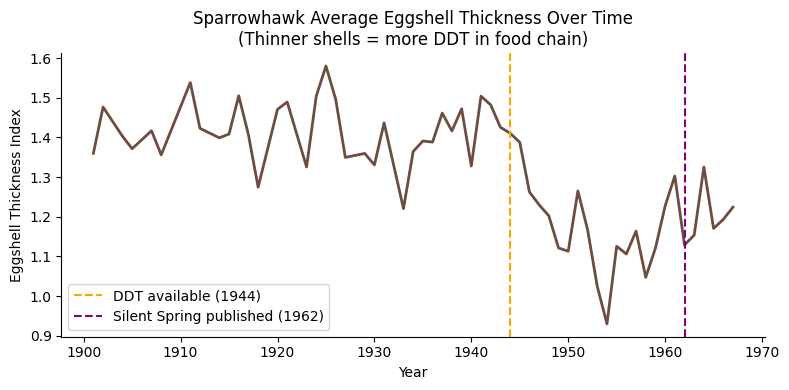

In [9]:
# ── 2. Eggshell thickness — DDT's impact on birds ─────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(egg['year'], egg['avg_thickness'], color='#6D4C41', linewidth=2)
plt.axvline(1944, color='orange', ls='--', linewidth=1.5, label='DDT available (1944)')
plt.axvline(1962, color='purple', ls='--', linewidth=1.5, label='Silent Spring published (1962)')
plt.xlabel('Year')
plt.ylabel('Eggshell Thickness Index')
plt.title('Sparrowhawk Average Eggshell Thickness Over Time\n(Thinner shells = more DDT in food chain)')
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

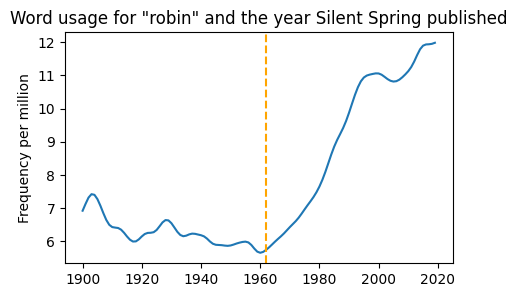

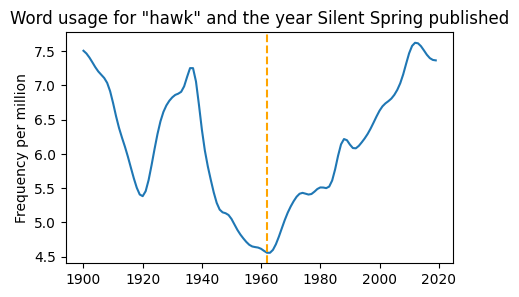

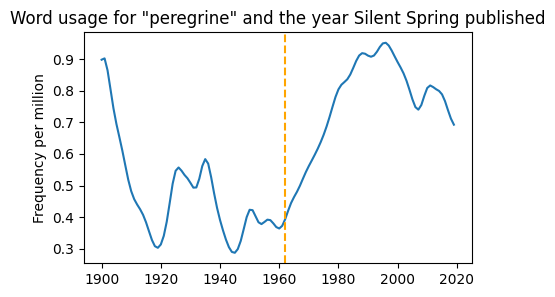

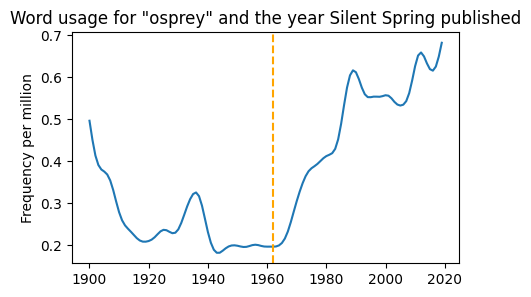

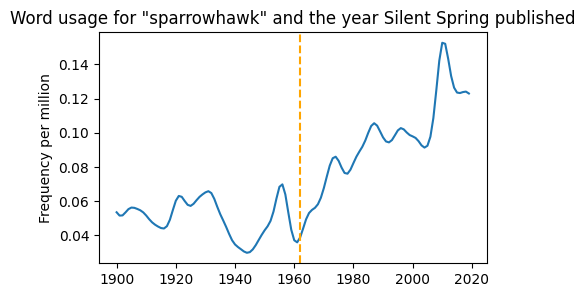

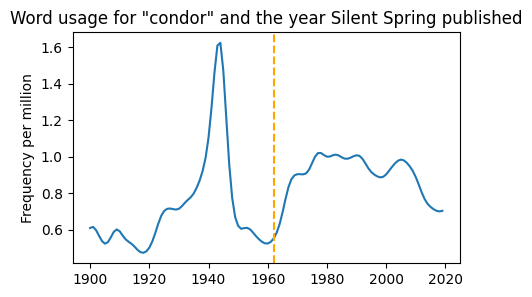

In [10]:
# ── 3. Bird word trends (relative to 1962 Silent Spring) ─────────────────────
birds = ['robin', 'hawk', 'peregrine', 'osprey', 'sparrowhawk', 'condor']

for bird in birds:
    plot_bird_word_trend(bird)

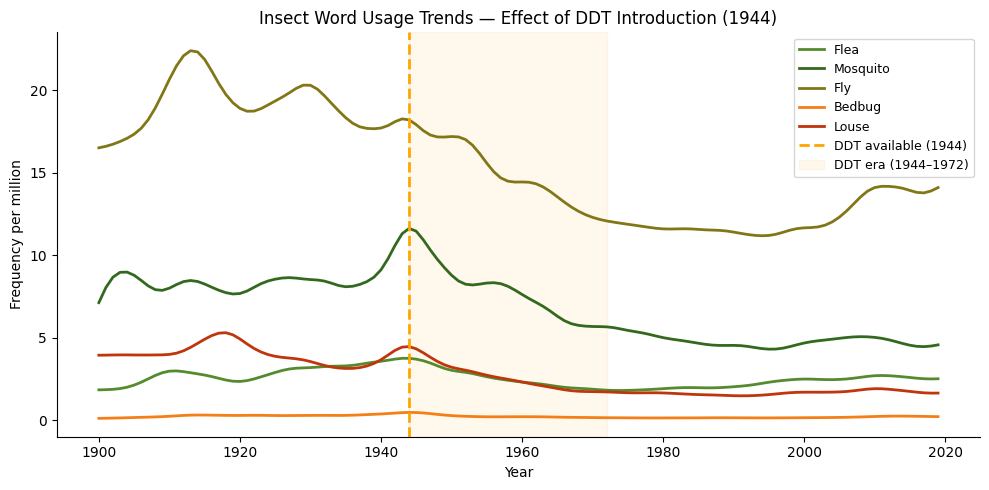

In [11]:
# ── 4. Combined: all insects on one chart ─────────────────────────────────────
plt.figure(figsize=(10, 5))

insect_colors = ['#558B2F', '#33691E', '#827717', '#F57F17', '#BF360C']
for insect, color in zip(insects, insect_colors):
    trend = df.query('word == @insect')
    plt.plot(trend['year'], trend['frequency'],
             label=insect.title(), color=color, linewidth=2)

plt.axvline(1944, color='orange', ls='--', linewidth=2, label='DDT available (1944)')
plt.axvspan(1944, 1972, color='orange', alpha=0.07, label='DDT era (1944–1972)')

plt.ylabel('Frequency per million')
plt.xlabel('Year')
plt.title('Insect Word Usage Trends — Effect of DDT Introduction (1944)')
plt.legend(fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

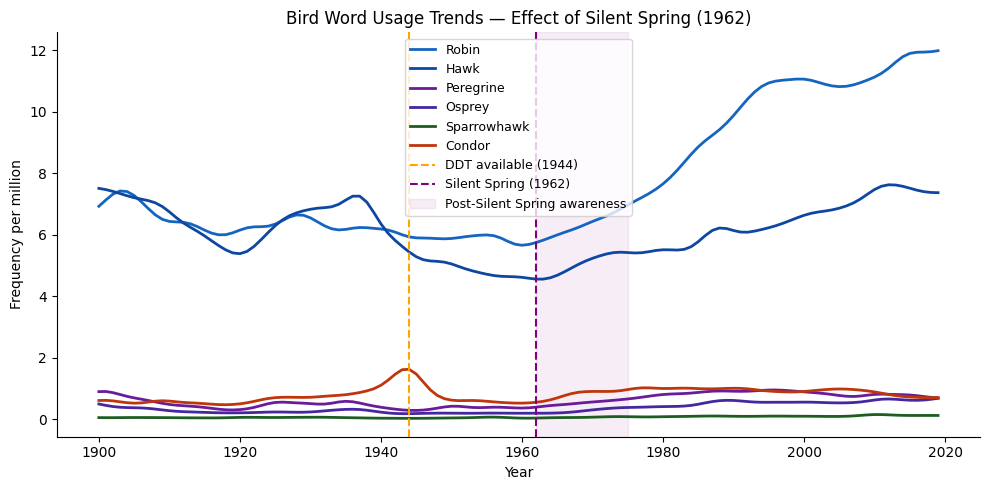

In [12]:
# ── 5. Combined: all birds on one chart ───────────────────────────────────────
plt.figure(figsize=(10, 5))

bird_colors = ['#1565C0', '#0D47A1', '#6A1B9A', '#4527A0', '#1B5E20', '#BF360C']
for bird, color in zip(birds, bird_colors):
    trend = df.query('word == @bird')
    if len(trend) > 0:
        plt.plot(trend['year'], trend['frequency'],
                 label=bird.title(), color=color, linewidth=2)

plt.axvline(1944, color='orange', ls='--', linewidth=1.5, label='DDT available (1944)')
plt.axvline(1962, color='purple', ls='--', linewidth=1.5, label='Silent Spring (1962)')
plt.axvspan(1962, 1975, color='purple', alpha=0.07, label='Post-Silent Spring awareness')

plt.ylabel('Frequency per million')
plt.xlabel('Year')
plt.title('Bird Word Usage Trends — Effect of Silent Spring (1962)')
plt.legend(fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# ── 6. Before vs after comparison: insects (1944) and birds (1962) ────────────
print("Insect Word Frequency: Before vs After DDT (1944)")
print("=" * 55)
print(f"{'Word':<12} {'Before 1944':>12} {'After 1944':>12} {'% Change':>10}")
print("-" * 55)
for insect in insects:
    trend = df.query('word == @insect')
    before = trend[trend['year'] < 1944]['frequency'].mean()
    after  = trend[trend['year'] >= 1944]['frequency'].mean()
    change = (after - before) / (before + 1e-9) * 100
    print(f"{insect:<12} {before:>12.3f} {after:>12.3f} {change:>+10.1f}%")

print()
print("Bird Word Frequency: Before vs After Silent Spring (1962)")
print("=" * 55)
print(f"{'Word':<14} {'Before 1962':>12} {'After 1962':>12} {'% Change':>10}")
print("-" * 55)
for bird in birds:
    trend = df.query('word == @bird')
    if len(trend) == 0:
        continue
    before = trend[trend['year'] < 1962]['frequency'].mean()
    after  = trend[trend['year'] >= 1962]['frequency'].mean()
    change = (after - before) / (before + 1e-9) * 100
    print(f"{bird:<14} {before:>12.3f} {after:>12.3f} {change:>+10.1f}%")

Insect Word Frequency: Before vs After DDT (1944)
Word          Before 1944   After 1944   % Change
-------------------------------------------------------
flea                2.834        2.366      -16.5%
mosquito            8.436        5.960      -29.4%
fly                19.089       13.316      -30.2%
bedbug              0.265        0.187      -29.6%
louse               4.005        2.025      -49.4%

Bird Word Frequency: Before vs After Silent Spring (1962)
Word            Before 1962   After 1962   % Change
-------------------------------------------------------
robin                 6.279        9.265      +47.6%
hawk                  6.065        6.148       +1.4%
peregrine             0.468        0.760      +62.4%
osprey                0.252        0.482      +91.1%
sparrowhawk           0.050        0.095      +88.8%
condor                0.719        0.895      +24.5%
